# Chapter 4: Use your own Batch Gradient Descent with Softmax classifier using Numpy Only

## Get the data

In [93]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [94]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [95]:
X = iris.data[["petal length (cm)", "petal width (cm)","sepal length (cm)","sepal width (cm)"]].values
y = iris["target"].values

Let's add the bias term to the training matrix

In [96]:
import numpy as np

X_with_bias = np.c_[np.ones((X.shape[0], 1)), X]  # add x0 = 1 to each instance

Let's shuffle and split the data set now

In [97]:
test_ratio = 0.2
validation_ratio = 0.2
total_size = len(X_with_bias)

test_size = int(total_size * test_ratio)
validation_size = int(total_size * validation_ratio)
train_size = total_size - test_size - validation_size

rng = np.random.default_rng(seed=42)
rnd_indices = rng.permutation(total_size)

X_train = X_with_bias[rnd_indices[:train_size]]
y_train = y[rnd_indices[:train_size]]

X_valid = X_with_bias[rnd_indices[train_size:-validation_size]]
y_valid = y[rnd_indices[train_size:-validation_size]]

X_test = X_with_bias[rnd_indices[-test_size:]]
y_test = y[rnd_indices[-test_size:]]

For softmax regression we will need probabilities for each classes so let's set probabilities to 0 when it's not the good class and 1 when it the good class, to do this let's onehot encode y

In [98]:
def to_one_hot(y):
    return np.diag(np.ones(y.max() + 1))[y]

In [99]:
y_train = to_one_hot(y_train)
y_valid = to_one_hot(y_valid)

In [100]:
print(y_train[:10]) 

[[0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [1. 0. 0.]]


In [101]:
print(np.unique(y_train,axis=0))

[[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]


Batch Gradient Descent will work better if the features are scaled so let's standardize those data. We use the same transformation as on train to every set

In [102]:
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)
X_train[:, 1:] = (X_train[:, 1:] - mean) / std
X_valid[:, 1:] = (X_valid[:, 1:] - mean) / std
X_test[:, 1:] = (X_test[:, 1:] - mean) / std

## Create the Softmax Classifier

In [ ]:
class SoftmaxRegressionBatchGD:
    def __init__(self,learning_rate=0.01,n_iteration=1000, early_stop = 100):
        self.learning_rate = learning_rate
        self.n_iteration = n_iteration
        self.early_stop = early_stop
        self.param_matrix = 0        
        return
    
    def fit(self,X,y,X_val,y_val):
        """
        This function will initialize the parameters of the parameters matrix 
        It will call iterativly the train function which will perform Batch Gradient Descent
        Early stopping is also implemented
        """
        
        # 1. Create the parameter space
        num_classes = len(np.unique(y,axis=0))
        num_parameters = X.shape[1]
        
        # Normal distribution of parameters
        self.param_matrix = np.random.randn(num_parameters,num_classes) * 0.1
        print(f"Random parameters matrix:\n{self.param_matrix}")
       
        train_losses = []
        val_losses = []
    
        i=0
        
        best_parameters = None
        
        min_val_loss = float('inf')
        count_no_min_update = 0
        # 2. Use training algorithm
        while i < self.n_iteration and count_no_min_update < self.early_stop :
            train_loss, val_loss = self.train_BatchGD(X,y,X_val,y_val)
            print(f"Epoch {i}: , train_loss={train_loss} , val_loss={val_loss}")
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            
            # Early stopping
            if val_loss < min_val_loss:
                best_parameters = self.param_matrix.copy()
                min_val_loss = val_loss
                count_no_min_update = 0  # Count reset
            else:
                count_no_min_update += 1
            
            i+=1
            
        # Restore best parameters
        if best_parameters is not None:
            self.param_matrix = best_parameters
        
        print(f"Training stopped at epoch {i}, val_loss = {min_val_loss}")
        
        return train_losses, val_losses
            
    def train_BatchGD(self,X,y,X_val,y_val) -> (float, float):
        """This function will compute the scores of the instances and then the estimated probabilities.
           It will next evaluate the prediction.
           Then it will compute the gradient of the loss function and update the weights.
        

        Args:
            X : input features
            y : target labels

        Returns:
            float, float: train and validation loss
        """
        
        # 1. Compute the scores
        
        # Matrix of score for each class for each instance ([[score_class_0,...,score_class_2],...])
        scores_train = X @ self.param_matrix
        scores_val = np.dot(X_val,self.param_matrix)
        
        # 2. Compute the estimated probabilities
        proba_matrix_train = self._softmax(scores_train)
        proba_matrix_val = self._softmax(scores_val)
        
        # 3. Evaluate train and val losses
        epsilon = 10e-15 # Avoid log(0)
        cross_entropy_loss_train = (- np.sum(y * np.log(proba_matrix_train + epsilon),axis=1)).mean()
        cross_entropy_loss_val = (- np.sum(y_val * np.log(proba_matrix_val + epsilon),axis=1)).mean()
                
        
        # 4. One round of batchGD
        gradient = (X.T @ (proba_matrix_train - y))/X.shape[0]

        self.param_matrix -= self.learning_rate*gradient
        
        return (cross_entropy_loss_train,cross_entropy_loss_val)
    
    def _softmax(self,scores):
        """For a n,m matrix computes the softmax score of each instance and each probability

        Args:
            scores (_type_): Matrix of scores (n,m)
        """
        
        # 1. exp_k(x)
        exp_scores = np.exp(scores)
          
        # 2. sum of exp
        sum_exp = np.sum(exp_scores,axis=1,keepdims=True)
    
        # 3. Probabilities
        probabilities = exp_scores / sum_exp
        
        return probabilities
    
    def predict(self,X):
        """For a given test set, the function will compute the scores and return a list of classes

        Args:
            X (_type_): Matrix(n,m)
        """
    
        scores = X @ self.param_matrix

        y_pred = np.argmax(scores,axis=1)
        
        return y_pred
    

In [104]:
softmax = SoftmaxRegressionBatchGD(n_iteration=200000,early_stop=1000)

train_losses, val_losses = softmax.fit(X_train,y_train,X_valid,y_valid)

Random parameters matrix:
[[ 0.0877434  -0.20120706  0.08469995]
 [-0.08024583  0.09049    -0.03768691]
 [ 0.14546363  0.06894051 -0.09147763]
 [-0.01607839 -0.15477555  0.16803769]
 [-0.04053826 -0.08113269  0.07980382]]
Epoch 0: , train_loss=1.142947610697808 , val_loss=1.1024425514148164
Epoch 1: , train_loss=1.1334577704477105 , val_loss=1.0914215025757805
Epoch 2: , train_loss=1.124158991551825 , val_loss=1.0806226846120268
Epoch 3: , train_loss=1.115047525015216 , val_loss=1.0700418275075416
Epoch 4: , train_loss=1.1061196420414439 , val_loss=1.0596746772861694
Epoch 5: , train_loss=1.097371637877784 , val_loss=1.049517000918408
Epoch 6: , train_loss=1.088799835417517 , val_loss=1.0395645909312892
Epoch 7: , train_loss=1.0804005885612291 , val_loss=1.0298132697226736
Epoch 8: , train_loss=1.0721702853400974 , val_loss=1.020258893582752
Epoch 9: , train_loss=1.064105350805049 , val_loss=1.0108973564268569
Epoch 10: , train_loss=1.0562022496865224 , val_loss=1.0017245932448424
Epoc

Epoch 2838: , train_loss=0.2357204496581317 , val_loss=0.17931573486727978
Epoch 2839: , train_loss=0.2356791714735312 , val_loss=0.1792873297259608
Epoch 2840: , train_loss=0.2356379118541883 , val_loss=0.17925893721794717
Epoch 2841: , train_loss=0.23559667078744131 , val_loss=0.17923055733482834
Epoch 2842: , train_loss=0.23555544826063993 , val_loss=0.17920219006820198
Epoch 2843: , train_loss=0.23551424426114578 , val_loss=0.17917383540967372
Epoch 2844: , train_loss=0.23547305877633162 , val_loss=0.17914549335085764
Epoch 2845: , train_loss=0.23543189179358193 , val_loss=0.17911716388337595
Epoch 2846: , train_loss=0.2353907433002926 , val_loss=0.17908884699885888
Epoch 2847: , train_loss=0.23534961328387108 , val_loss=0.179060542688945
Epoch 2848: , train_loss=0.23530850173173626 , val_loss=0.17903225094528086
Epoch 2849: , train_loss=0.23526740863131834 , val_loss=0.1790039717595212
Epoch 2850: , train_loss=0.2352263339700593 , val_loss=0.17897570512332894
Epoch 2851: , train_l

Let's take a look to the learning curves

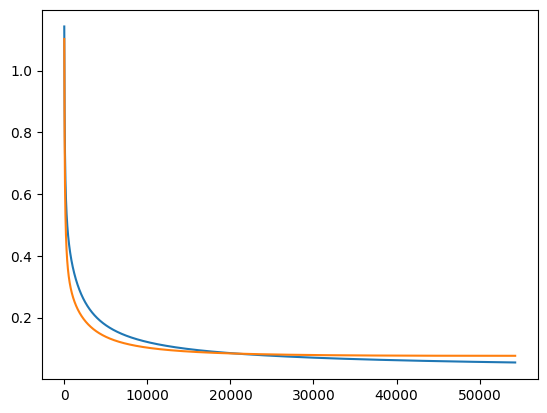

In [105]:
import matplotlib.pyplot as plt

plt.plot(range(len(train_losses)),train_losses)
plt.plot(range(len(val_losses)),val_losses)

In [106]:
y_pred = softmax.predict(X_test)
print(y_pred)

[2 0 0 2 2 1 2 1 0 0 1 0 1 0 0 2 2 0 2 0 0 1 0 2 2 0 2 0 1 2]


In [107]:
accuracy_score = (y_pred == y_test).mean()
accuracy_score

np.float64(1.0)

In [108]:
from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]
X_new = (X_new - mean) / std
X_new_with_bias = np.c_[np.ones(len(X_new)), X_new]

logits = X_new_with_bias @ Theta
Y_proba = softmax(logits)
y_predict = Y_proba.argmax(axis=1)

zz1 = Y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y == 2, 0], X[y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[y == 1, 0], X[y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[y == 0, 0], X[y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="upper left")
plt.axis([0, 7, 0, 3.5])
plt.grid()

ValueError: operands could not be broadcast together with shapes (100000,2) (4,) 